In [1]:
!pip install -q -U transformers accelerate
!pip install -q peft trl bitsandbytes datasets scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 159.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.9 MB/s eta 0:00:00


In [2]:
import torch
import time
import gc
import re
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
print("✅ All imports loaded!")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB (42.4 GB)
✅ All imports loaded!


In [3]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("Assassin.csv", low_memory=False)
df = df.dropna(subset=['body', 'subject'])
df['body'] = df['body'].astype(str)
df['subject'] = df['subject'].astype(str)
df['body_truncated'] = df['body'].str[:1000]

print(f"Total: {len(df)} | Phishing: {(df['label']==1).sum()} | Benign: {(df['label']==0).sum()}")

# Stratified sample: 500 total
subset, _ = train_test_split(df, train_size=500, stratify=df['label'], random_state=42)
train_df, test_df = train_test_split(subset, test_size=0.2, stratify=subset['label'], random_state=42)

print(f"Train: {len(train_df)} (P:{(train_df['label']==1).sum()} B:{(train_df['label']==0).sum()})")
print(f"Test:  {len(test_df)} (P:{(test_df['label']==1).sum()} B:{(test_df['label']==0).sum()})")

Total: 5792 | Phishing: 1705 | Benign: 4087
Train: 400 (P:118 B:282)
Test:  100 (P:29 B:71)


In [4]:
SYSTEM_PROMPT = """You are a phishing email detection assistant. Analyze the email and determine if it is phishing or legitimate.
Answer with ONLY one word: "phishing" or "legitimate"."""

def email_to_prompt(row):
    sender = str(row.get('sender', 'Unknown'))[:100]
    subject = str(row.get('subject', '(no subject)'))[:200]
    body = str(row.get('body_truncated', ''))[:1000]
    return f"Subject: {subject}\n\nFrom: {sender}\n\nEmail Content:\n{body}"

def email_to_label(row):
    return "phishing" if row['label'] == 1 else "legitimate"

# Test
sample = train_df.iloc[0]
print("=== SAMPLE PROMPT ===")
print(email_to_prompt(sample)[:400])
print(f"\n=== LABEL: {email_to_label(sample)} ===")

=== SAMPLE PROMPT ===
Subject: Kime Oy Vereceksiniz ?

From: ankara@dunyagazetesi.com.tr

Email Content:
=DDyi g=FCnler

=20
D=DCNYA Gazetesi, i=E7inde bulundu=F0umuz siyasi karma=FEa d=F6neminin se=
=E7imler sonras=FDnda nas=FDl bir hal alaca=F0=FD konusunda kapsaml=FD bi=
r ara=FEt=FDrma yapmaktad=FDr. Bu =E7er=E7evede toplumumuzun m=FCmk=FCn o=
ldu=F0unca geni=FE bir kesiminin g=F6r=FC=FElerine ba=FEvurmay=FD gerekl

=== LABEL: phishing ===


In [5]:
ALL_RESULTS = {}

def load_model_4bit(model_name):
    """Load model with 4-bit quantization (for Mistral, Llama)."""
    print(f"\n{'='*60}")
    print(f"Loading: {model_name} (4-bit)")
    print(f"{'='*60}")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name, quantization_config=bnb_config,
        device_map="auto", trust_remote_code=True,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = model.config.eos_token_id
    tokenizer.padding_side = "right"
    print(f"✅ Loaded! Params: {sum(p.numel() for p in model.parameters()):,}")
    return model, tokenizer


def load_model_bf16(model_name):
    """Load model in bf16 (for Qwen3.5 — QLoRA not recommended)."""
    print(f"\n{'='*60}")
    print(f"Loading: {model_name} (bf16)")
    print(f"{'='*60}")
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=torch.bfloat16,
        device_map="auto", trust_remote_code=True,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = model.config.eos_token_id
    tokenizer.padding_side = "right"
    print(f"✅ Loaded! Params: {sum(p.numel() for p in model.parameters()):,}")
    return model, tokenizer


def ask(model, tokenizer, user_input, max_tokens=20):
    """Generate a response — short, just classification."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_input},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,               # Greedy = deterministic
            pad_token_id=tokenizer.pad_token_id,
        )
    response = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    # Strip any thinking tags
    response = re.sub(r'<think>.*?</think>', '', response, flags=re.DOTALL).strip()
    response = re.sub(r'<think>.*', '', response, flags=re.DOTALL).strip()
    return response.strip()


def extract_prediction(response):
    """Extract phishing(1) or legitimate(0) from response."""
    resp = response.lower().strip()
    # Direct match
    if resp.startswith("phishing"):
        return 1
    if resp.startswith("legitimate"):
        return 0
    # Search in text
    if "phishing" in resp and "legitimate" not in resp:
        return 1
    if "legitimate" in resp and "phishing" not in resp:
        return 0
    if "spam" in resp:
        return 1
    if "benign" in resp or "safe" in resp or "not phishing" in resp:
        return 0
    # If both present, first one wins
    p_pos = resp.find("phishing")
    l_pos = resp.find("legitimate")
    if p_pos != -1 and l_pos != -1:
        return 1 if p_pos < l_pos else 0
    return -1  # Can't determine


def evaluate_model(model, tokenizer, label, test_data, num_samples=50):
    """Evaluate on test set with full metrics."""
    print(f"\n📊 Evaluating: {label} ({num_samples} samples)...")
    y_true, y_pred, failures = [], [], 0

    for i, (_, row) in enumerate(test_data.head(num_samples).iterrows()):
        if i % 10 == 0:
            print(f"  {i+1}/{num_samples}...")
        response = ask(model, tokenizer, email_to_prompt(row))
        pred = extract_prediction(response)
        y_true.append(row['label'])
        if pred == -1:
            failures += 1
            y_pred.append(0)
        else:
            y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"  Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f} | Failures: {failures}")

    ALL_RESULTS[label] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'y_true': y_true, 'y_pred': y_pred, 'failures': failures,
    }
    return acc, f1


def prepare_sft_dataset(tokenizer, train_data):
    """Format training data — prompt + one-word answer."""
    formatted = []
    for _, row in train_data.iterrows():
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": email_to_prompt(row)},
            {"role": "assistant", "content": email_to_label(row)},
        ]
        text = tokenizer.apply_chat_template(messages, tokenize=False)
        formatted.append({"text": text})
    return Dataset.from_list(formatted)


def setup_lora(model, alpha=16):
    """Apply LoRA adapter."""
    model = prepare_model_for_kbit_training(model)
    config = LoraConfig(
        r=16, lora_alpha=alpha,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                         "gate_proj", "up_proj", "down_proj"],
        lora_dropout=0, bias="none", task_type="CAUSAL_LM",
    )
    model = get_peft_model(model, config)
    trainable, total = model.get_nb_trainable_parameters()
    print(f"  LoRA: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    return model


def fine_tune(model, tokenizer, train_dataset, eval_dataset, output_dir, epochs=3):
    """Fine-tune with eval during training."""
    args = SFTConfig(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        warmup_steps=50,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        bf16=True,
        dataset_text_field="text",
        packing=False,
        max_length=2048,
        optim="adamw_8bit",
        seed=42,
        report_to="none",
    )
    trainer = SFTTrainer(
        model=model, args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
    )
    print(f"  Training {len(train_dataset)} examples, {epochs} epochs...")
    start = time.time()
    trainer.train()
    duration = time.time() - start
    print(f"  ✅ Done in {duration/60:.1f} min")
    return duration


def cleanup():
    gc.collect()
    torch.cuda.empty_cache()
    print("🧹 GPU cleared.")


NUM_TEST_SAMPLES = 50
print("✅ All functions loaded!")

✅ All functions loaded!


In [ ]:
# TODO: Add your Hugging Face login here before running this notebook.
# from huggingface_hub import login
# login(token="YOUR_HUGGINGFACE_TOKEN_HERE")

In [7]:
# Qwen3.5 — loaded in bf16, NOT 4-bit (per official recommendation)
model1, tok1 = load_model_bf16("Qwen/Qwen3.5-2B")

# Baseline
acc1_b, f1_1_b = evaluate_model(model1, tok1, "Qwen3.5-2B (baseline)", test_df, NUM_TEST_SAMPLES)

# Show sample responses
print("\nSample responses:")
for label_val, label_name in [(1, "PHISHING"), (0, "BENIGN")]:
    sample = test_df[test_df['label']==label_val].iloc[0]
    resp = ask(model1, tok1, email_to_prompt(sample))
    print(f"  [{label_name}] → Model says: '{resp}'")


Loading: Qwen/Qwen3.5-2B (bf16)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

✅ Loaded! Params: 1,881,825,088

📊 Evaluating: Qwen3.5-2B (baseline) (50 samples)...
  1/50...
  11/50...
  21/50...
  31/50...
  41/50...
  Accuracy: 0.340 | Precision: 0.267 | Recall: 1.000 | F1: 0.421 | Failures: 0

Sample responses:
  [PHISHING] → Model says: 'phishing'
  [BENIGN] → Model says: 'phishing'


In [8]:
train_ds1 = prepare_sft_dataset(tok1, train_df)

# Split training data for eval during training
eval_split = prepare_sft_dataset(tok1, test_df)

model1 = setup_lora(model1, alpha=16)
time1 = fine_tune(model1, tok1, train_ds1, eval_split, "./qwen35-2b-phishing")

# After fine-tuning
acc1_ft, f1_1_ft = evaluate_model(model1, tok1, "Qwen3.5-2B (fine-tuned)", test_df, NUM_TEST_SAMPLES)

print("\nFine-tuned sample responses:")
for label_val, label_name in [(1, "PHISHING"), (0, "BENIGN")]:
    sample = test_df[test_df['label']==label_val].iloc[0]
    resp = ask(model1, tok1, email_to_prompt(sample))
    print(f"  [{label_name}] → Model says: '{resp}'")

del model1, tok1, train_ds1, eval_split
cleanup()

  LoRA: 10,911,744 / 1,892,736,832 (0.58%)


Adding EOS to train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.


  Training 400 examples, 3 epochs...


Epoch,Training Loss,Validation Loss
1,2.823927,2.568357
2,2.362998,2.382425
3,2.258476,2.322584


  ✅ Done in 10.1 min

📊 Evaluating: Qwen3.5-2B (fine-tuned) (50 samples)...
  1/50...
  11/50...
  21/50...
  31/50...
  41/50...
  Accuracy: 0.980 | Precision: 0.923 | Recall: 1.000 | F1: 0.960 | Failures: 0

Fine-tuned sample responses:
  [PHISHING] → Model says: 'phishing'
  [BENIGN] → Model says: 'legitimate'
🧹 GPU cleared.


In [9]:
model2, tok2 = load_model_bf16("Qwen/Qwen3.5-4B")
acc2_b, f1_2_b = evaluate_model(model2, tok2, "Qwen3.5-4B (baseline)", test_df, NUM_TEST_SAMPLES)

print("\nSample responses:")
for label_val, label_name in [(1, "PHISHING"), (0, "BENIGN")]:
    sample = test_df[test_df['label']==label_val].iloc[0]
    resp = ask(model2, tok2, email_to_prompt(sample))
    print(f"  [{label_name}] → Model says: '{resp}'")


Loading: Qwen/Qwen3.5-4B (bf16)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

✅ Loaded! Params: 4,205,751,296

📊 Evaluating: Qwen3.5-4B (baseline) (50 samples)...
  1/50...
  11/50...
  21/50...
  31/50...
  41/50...
  Accuracy: 0.760 | Precision: 0.000 | Recall: 0.000 | F1: 0.000 | Failures: 50

Sample responses:
  [PHISHING] → Model says: 'Thinking Process:

1.  **Analyze the Request:**
    *   Task: Determine'
  [BENIGN] → Model says: 'Thinking Process:

1.  **Analyze the Request:**
    *   Task: Ph'


In [10]:
train_ds2 = prepare_sft_dataset(tok2, train_df)
eval_ds2 = prepare_sft_dataset(tok2, test_df)
model2 = setup_lora(model2, alpha=16)
time2 = fine_tune(model2, tok2, train_ds2, eval_ds2, "./qwen35-4b-phishing")
acc2_ft, f1_2_ft = evaluate_model(model2, tok2, "Qwen3.5-4B (fine-tuned)", test_df, NUM_TEST_SAMPLES)

print("\nFine-tuned sample responses:")
for label_val, label_name in [(1, "PHISHING"), (0, "BENIGN")]:
    sample = test_df[test_df['label']==label_val].iloc[0]
    resp = ask(model2, tok2, email_to_prompt(sample))
    print(f"  [{label_name}] → Model says: '{resp}'")

del model2, tok2, train_ds2, eval_ds2
cleanup()

  LoRA: 21,233,664 / 4,226,984,960 (0.50%)


Adding EOS to train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.


  Training 400 examples, 3 epochs...


Epoch,Training Loss,Validation Loss
1,2.622710,2.377732
2,2.148891,2.169816
3,2.037312,2.111246


  ✅ Done in 14.3 min

📊 Evaluating: Qwen3.5-4B (fine-tuned) (50 samples)...
  1/50...
  11/50...
  21/50...
  31/50...
  41/50...
  Accuracy: 0.360 | Precision: 0.262 | Recall: 0.917 | F1: 0.407 | Failures: 7

Fine-tuned sample responses:
  [PHISHING] → Model says: 'The user wants to determine if the email is phishing or legitimate.

1.  **Analyze'
  [BENIGN] → Model says: 'This is an email detection task. I need to analyze whether this email is phishing or legitimate.'
🧹 GPU cleared.


In [11]:
model3, tok3 = load_model_4bit("mistralai/Mistral-7B-Instruct-v0.3")
acc3_b, f1_3_b = evaluate_model(model3, tok3, "Mistral-7B (baseline)", test_df, NUM_TEST_SAMPLES)

print("\nSample responses:")
for label_val, label_name in [(1, "PHISHING"), (0, "BENIGN")]:
    sample = test_df[test_df['label']==label_val].iloc[0]
    resp = ask(model3, tok3, email_to_prompt(sample))
    print(f"  [{label_name}] → Model says: '{resp}'")


Loading: mistralai/Mistral-7B-Instruct-v0.3 (4-bit)


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✅ Loaded! Params: 3,758,362,624

📊 Evaluating: Mistral-7B (baseline) (50 samples)...
  1/50...
  11/50...
  21/50...
  31/50...
  41/50...
  Accuracy: 0.240 | Precision: 0.240 | Recall: 1.000 | F1: 0.387 | Failures: 0

Sample responses:
  [PHISHING] → Model says: 'Phishing'
  [BENIGN] → Model says: '"phishing"'


In [12]:
train_ds3 = prepare_sft_dataset(tok3, train_df)
eval_ds3 = prepare_sft_dataset(tok3, test_df)
model3 = setup_lora(model3, alpha=16)
time3 = fine_tune(model3, tok3, train_ds3, eval_ds3, "./mistral-7b-phishing")
acc3_ft, f1_3_ft = evaluate_model(model3, tok3, "Mistral-7B (fine-tuned)", test_df, NUM_TEST_SAMPLES)

print("\nFine-tuned sample responses:")
for label_val, label_name in [(1, "PHISHING"), (0, "BENIGN")]:
    sample = test_df[test_df['label']==label_val].iloc[0]
    resp = ask(model3, tok3, email_to_prompt(sample))
    print(f"  [{label_name}] → Model says: '{resp}'")

del model3, tok3, train_ds3, eval_ds3
cleanup()

  LoRA: 41,943,040 / 7,289,966,592 (0.58%)


Adding EOS to train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


  Training 400 examples, 3 epochs...


Epoch,Training Loss,Validation Loss
1,2.386023,2.290420
2,2.009191,2.074919
3,1.713605,2.034657


  ✅ Done in 4.8 min

📊 Evaluating: Mistral-7B (fine-tuned) (50 samples)...
  1/50...
  11/50...
  21/50...
  31/50...
  41/50...
  Accuracy: 0.840 | Precision: 0.600 | Recall: 1.000 | F1: 0.750 | Failures: 0

Fine-tuned sample responses:
  [PHISHING] → Model says: 'phishing'
  [BENIGN] → Model says: 'legitimate'
🧹 GPU cleared.


In [14]:
model4, tok4 = load_model_4bit("meta-llama/Llama-3.2-3B-Instruct")
acc4_b, f1_4_b = evaluate_model(model4, tok4, "Llama-3.2-3B (baseline)", test_df, NUM_TEST_SAMPLES)

print("\nSample responses:")
for label_val, label_name in [(1, "PHISHING"), (0, "BENIGN")]:
    sample = test_df[test_df['label']==label_val].iloc[0]
    resp = ask(model4, tok4, email_to_prompt(sample))
    print(f"  [{label_name}] → Model says: '{resp}'")


Loading: meta-llama/Llama-3.2-3B-Instruct (4-bit)


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✅ Loaded! Params: 1,803,463,680

📊 Evaluating: Llama-3.2-3B (baseline) (50 samples)...
  1/50...
  11/50...
  21/50...
  31/50...
  41/50...
  Accuracy: 0.480 | Precision: 0.316 | Recall: 1.000 | F1: 0.480 | Failures: 0

Sample responses:
  [PHISHING] → Model says: 'phishing'
  [BENIGN] → Model says: 'phishing'


In [15]:
train_ds4 = prepare_sft_dataset(tok4, train_df)
eval_ds4 = prepare_sft_dataset(tok4, test_df)
model4 = setup_lora(model4, alpha=16)
time4 = fine_tune(model4, tok4, train_ds4, eval_ds4, "./llama-3.2-3b-phishing")
acc4_ft, f1_4_ft = evaluate_model(model4, tok4, "Llama-3.2-3B (fine-tuned)", test_df, NUM_TEST_SAMPLES)

print("\nFine-tuned sample responses:")
for label_val, label_name in [(1, "PHISHING"), (0, "BENIGN")]:
    sample = test_df[test_df['label']==label_val].iloc[0]
    resp = ask(model4, tok4, email_to_prompt(sample))
    print(f"  [{label_name}] → Model says: '{resp}'")

del model4, tok4, train_ds4, eval_ds4
cleanup()

  LoRA: 24,313,856 / 3,237,063,680 (0.75%)


Adding EOS to train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


  Training 400 examples, 3 epochs...


Epoch,Training Loss,Validation Loss
1,3.205196,2.691303
2,2.345609,2.364669
3,2.222218,2.284298


  ✅ Done in 3.6 min

📊 Evaluating: Llama-3.2-3B (fine-tuned) (50 samples)...
  1/50...
  11/50...
  21/50...
  31/50...
  41/50...
  Accuracy: 1.000 | Precision: 1.000 | Recall: 1.000 | F1: 1.000 | Failures: 0

Fine-tuned sample responses:
  [PHISHING] → Model says: 'phishing'
  [BENIGN] → Model says: 'legitimate'
🧹 GPU cleared.


In [16]:
print("=" * 85)
print("📊 MULTI-MODEL COMPARISON — PHISHING EMAIL DETECTION")
print("=" * 85)
print(f"Dataset: SpamAssassin | Train: {len(train_df)} | Test: {NUM_TEST_SAMPLES}")
print(f"Method: LoRA r=16 alpha=16 | lr=2e-4 | 3 epochs | adamw_8bit")
print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print()

models = [
    ("Qwen3.5-2B", "Qwen3.5-2B (baseline)", "Qwen3.5-2B (fine-tuned)"),
    ("Qwen3.5-4B", "Qwen3.5-4B (baseline)", "Qwen3.5-4B (fine-tuned)"),
    ("Mistral-7B", "Mistral-7B (baseline)", "Mistral-7B (fine-tuned)"),
    ("Llama-3.2-3B", "Llama-3.2-3B (baseline)", "Llama-3.2-3B (fine-tuned)"),
]

print(f"{'Model':<16} │ {'--- Baseline ---':^27} │ {'--- Fine-tuned ---':^27} │ {'ΔF1':^7}")
print(f"{'':16} │ {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} │ {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} │")
print("─" * 85)

for name, bk, fk in models:
    if bk in ALL_RESULTS and fk in ALL_RESULTS:
        b = ALL_RESULTS[bk]
        f = ALL_RESULTS[fk]
        d = f['f1'] - b['f1']
        ds = f"+{d:.2f}" if d >= 0 else f"{d:.2f}"
        print(f"{name:<16} │ {b['accuracy']:.3f} {b['precision']:.3f} {b['recall']:.3f} {b['f1']:.3f} │ {f['accuracy']:.3f} {f['precision']:.3f} {f['recall']:.3f} {f['f1']:.3f} │ {ds:>6}")
    elif bk in ALL_RESULTS:
        b = ALL_RESULTS[bk]
        print(f"{name:<16} │ {b['accuracy']:.3f} {b['precision']:.3f} {b['recall']:.3f} {b['f1']:.3f} │ {'(not run)':^27} │")
    else:
        print(f"{name:<16} │ {'(not run)':^27} │ {'(not run)':^27} │")

print("─" * 85)

print("\n\n📋 DETAILED REPORTS:")
for name, bk, fk in models:
    for key in [bk, fk]:
        if key in ALL_RESULTS:
            r = ALL_RESULTS[key]
            print(f"\n--- {key} ---")
            print(classification_report(r['y_true'], r['y_pred'],
                  target_names=['Legitimate', 'Phishing'], digits=3, zero_division=0))

print("\n🏆 KEY FINDINGS:")
for name, bk, fk in models:
    if bk in ALL_RESULTS and fk in ALL_RESULTS:
        d = ALL_RESULTS[fk]['f1'] - ALL_RESULTS[bk]['f1']
        status = "✅ IMPROVED" if d > 0.01 else "⚠️ WORSE" if d < -0.01 else "➡️ SAME"
        print(f"  {name}: {status} (F1: {ALL_RESULTS[bk]['f1']:.3f} → {ALL_RESULTS[fk]['f1']:.3f}, Δ={d:+.3f})")

📊 MULTI-MODEL COMPARISON — PHISHING EMAIL DETECTION
Dataset: SpamAssassin | Train: 400 | Test: 50
Method: LoRA r=16 alpha=16 | lr=2e-4 | 3 epochs | adamw_8bit
Date: 2026-03-12 06:43

Model            │      --- Baseline ---       │     --- Fine-tuned ---      │   ΔF1  
                 │    Acc   Prec    Rec     F1 │    Acc   Prec    Rec     F1 │
─────────────────────────────────────────────────────────────────────────────────────
Qwen3.5-2B       │ 0.340 0.267 1.000 0.421 │ 0.980 0.923 1.000 0.960 │  +0.54
Qwen3.5-4B       │ 0.760 0.000 0.000 0.000 │ 0.360 0.262 0.917 0.407 │  +0.41
Mistral-7B       │ 0.240 0.240 1.000 0.387 │ 0.840 0.600 1.000 0.750 │  +0.36
Llama-3.2-3B     │ 0.480 0.316 1.000 0.480 │ 1.000 1.000 1.000 1.000 │  +0.52
─────────────────────────────────────────────────────────────────────────────────────


📋 DETAILED REPORTS:

--- Qwen3.5-2B (baseline) ---
              precision    recall  f1-score   support

  Legitimate      1.000     0.132     0.233        38
    P

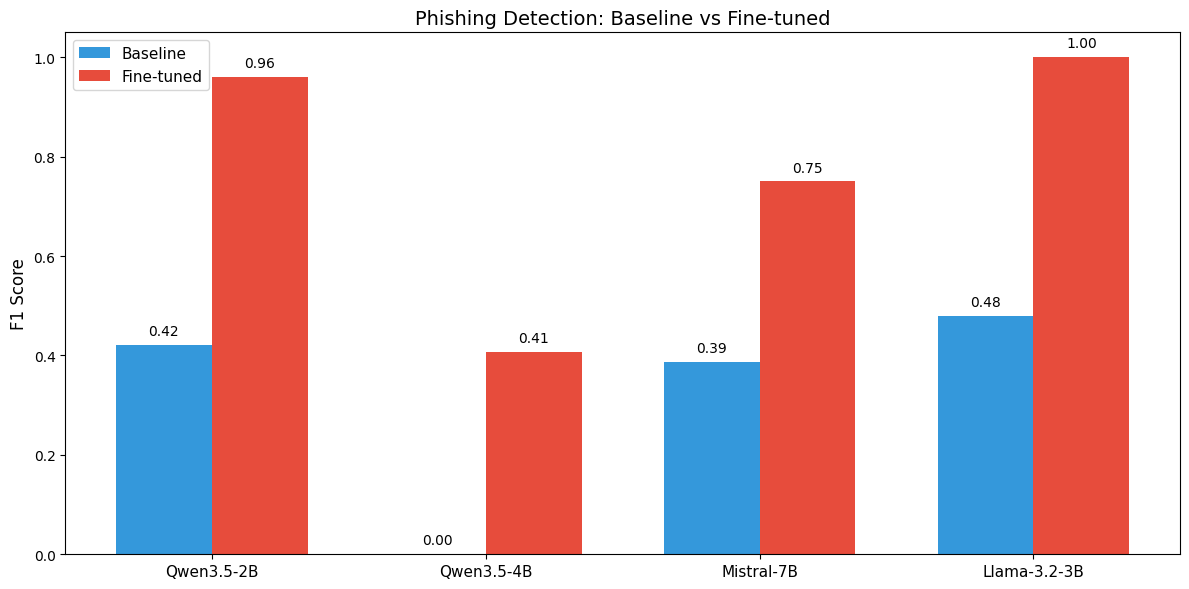

In [17]:
import matplotlib.pyplot as plt

model_names, base_f1s, ft_f1s = [], [], []
for name, bk, fk in models:
    if bk in ALL_RESULTS and fk in ALL_RESULTS:
        model_names.append(name)
        base_f1s.append(ALL_RESULTS[bk]['f1'])
        ft_f1s.append(ALL_RESULTS[fk]['f1'])

if model_names:
    x = np.arange(len(model_names))
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - 0.175, base_f1s, 0.35, label='Baseline', color='#3498db')
    bars2 = ax.bar(x + 0.175, ft_f1s, 0.35, label='Fine-tuned', color='#e74c3c')
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title('Phishing Detection: Baseline vs Fine-tuned', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 1.05)
    for b in bars1 + bars2:
        ax.text(b.get_x() + b.get_width()/2., b.get_height() + 0.02,
                f'{b.get_height():.2f}', ha='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('comparison.png', dpi=150)
    plt.show()